<a href="https://colab.research.google.com/github/Dikshant2898/Deakin-T1-2026/blob/main/MIS710A1_Dikshant_225742771.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIS710 Machine Learning in Business - Assignment 1

**Student Name:** DIKSHANT

**Student ID:** 225742771

In [29]:
# Load required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


# Load data
url = "https://raw.githubusercontent.com/Dikshant2898/Deakin-T1-2026/refs/heads/main/AESC_%20CO2e_data.csv"
df = pd.read_csv(url)

print(df.shape)       # How many rows and columns
df.head()             # First 5 rows
df.info()             # Data types and non-null counts

print("\n                                                      Summary Statistics ")
df.describe(include='all')         # Summary statistics for all columns


(6685, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6685 entries, 0 to 6684
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dealer_ID          6685 non-null   object 
 1   Dealer_State       6685 non-null   object 
 2   Make               6685 non-null   object 
 3   Vehicle Category   6685 non-null   object 
 4   Vehicle Colour     6485 non-null   object 
 5   Listing Month      6685 non-null   object 
 6   Transmission Type  6418 non-null   object 
 7   Fuel Type          6685 non-null   object 
 8   Cylinders          6518 non-null   float64
 9   Engine Size        6485 non-null   float64
 10  CO2 Emissions      6685 non-null   float64
dtypes: float64(3), object(8)
memory usage: 574.6+ KB

                                                      Summary Statistics 


,Dealer_ID,Dealer_State,Make,Vehicle Category,Vehicle Colour,Listing Month,Transmission Type,Fuel Type,Cylinders,Engine Size,CO2 Emissions
count,6685,6685,6685,6685,6485,6685,6418,6685,6518.000000,6485.000000,6685.000000
unique,60,7,42,16,11,12,27,5,NaN,NaN,NaN
top,D056,NSW,FORD,SUV - SMALL,White,Nov,AS6,X,NaN,NaN,NaN
freq,140,1863,578,1098,1672,668,1165,3290,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.629948,3.182378,250.734323
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.850539,1.413165,58.709821
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.900000,96.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,2.000000,208.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,3.000000,246.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,3.700000,289.000000


In [30]:
# Code for checking missing values
for col in df.columns:
    miss = df[col].isna().sum()
    print(col, 'missing:', miss)

Dealer_ID missing: 0
Dealer_State missing: 0
Make missing: 0
Vehicle Category missing: 0
Vehicle Colour missing: 200
Listing Month missing: 0
Transmission Type missing: 267
Fuel Type missing: 0
Cylinders missing: 167
Engine Size missing: 200
CO2 Emissions missing: 0


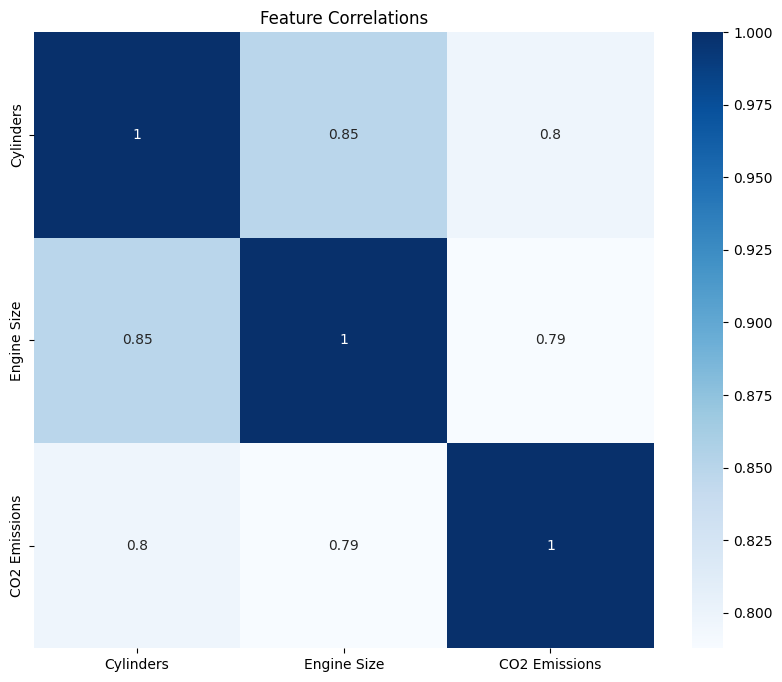

In [31]:
#Correlation heatmap

plt.figure(figsize=(10, 8))
numerical_variables = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numerical_variables].corr(), annot=True, cmap='Blues')
plt.title('Feature Correlations')
plt.show()

In [32]:
#Data Cleaning

for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col} unique values: {df[col].unique()[:10]}")

#Replace 'Unknown' with NaN
df.replace('Unknown', np.nan, inplace=True)


df.isnull().sum()

Dealer_ID unique values: ['D003' 'D027' 'D016' 'D025' 'D020' 'D011' 'D041' 'D029' 'D006' 'D051']
Dealer_State unique values: ['WA' 'VIC' 'NSW' 'QLD' 'TAS' 'SA' 'Unknown']
Make unique values: ['PORSCHE' 'BMW' 'GMC' 'CHEVROLET' 'TOYOTA' 'FORD' 'JAGUAR' 'VOLKSWAGEN'
 'KIA' 'SUBARU']
Vehicle Category unique values: ['FULL-SIZE' 'SUBCOMPACT' 'PICKUP TRUCK - STANDARD' 'SUV - STANDARD'
 'TWO-SEATER' 'COMPACT' 'SUV - SMALL' 'PICKUP TRUCK - SMALL' 'MID-SIZE'
 'MINICOMPACT']
Vehicle Colour unique values: ['Orange' 'Brown' 'Red' 'Black' 'Blue' 'Green' 'Silver' nan 'Grey' 'White']
Listing Month unique values: ['Oct' 'Jul' 'Jun' 'Nov' 'Sep' 'Feb' 'May' 'Apr' 'Mar' 'Aug']
Transmission Type unique values: ['AM8' 'AM7' 'A8' 'A6' 'AS5' 'AS8' 'AM6' 'AS6' 'M6' 'A4']
Fuel Type unique values: ['Z' 'X' 'E' 'D' 'N']


,0
Dealer_ID,0
Dealer_State,69
Make,0
Vehicle Category,0
Vehicle Colour,330
Listing Month,0
Transmission Type,267
Fuel Type,0
Cylinders,167
Engine Size,200


In [33]:
#Impute missing values

# For numeric columns,we use median

numeric_cols = ['Cylinders', 'Engine Size', 'CO2 Emissions']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# For categorical columns,we use mode
categorical_cols = ['Dealer_State', 'Vehicle Colour', 'Transmission Type', 'Fuel Type']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


df.isnull().sum()

,0
Dealer_ID,0
Dealer_State,0
Make,0
Vehicle Category,0
Vehicle Colour,0
Listing Month,0
Transmission Type,0
Fuel Type,0
Cylinders,0
Engine Size,0


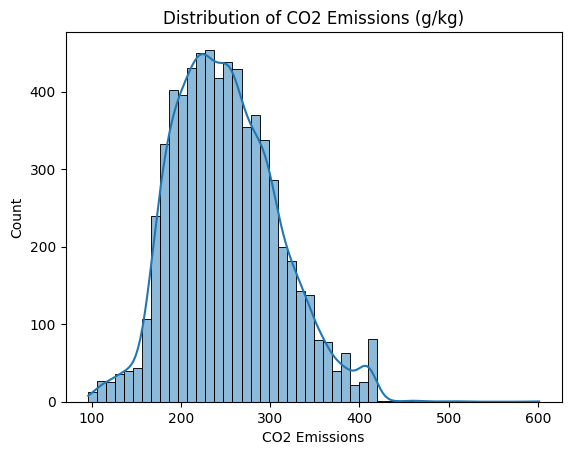

In [34]:
#Distribution of the target variable

sns.histplot(data=df, x='CO2 Emissions', kde=True, bins=50)
plt.title('Distribution of CO2 Emissions (g/kg)')
plt.show()

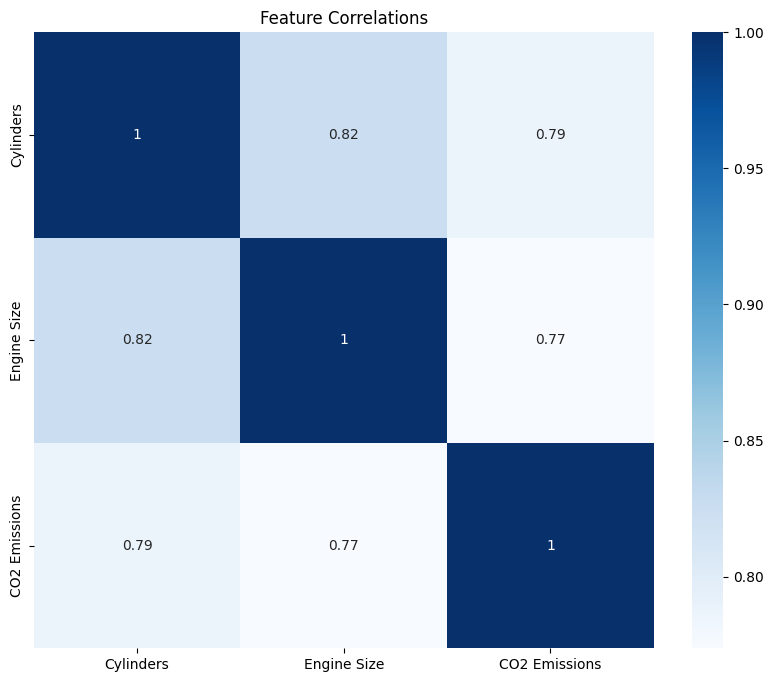

In [35]:
#Correlation heatmap

plt.figure(figsize=(10, 8))
numerical_variables = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numerical_variables].corr(), annot=True, cmap='Blues')
plt.title('Feature Correlations')
plt.show()

1st percentile (q1): 129.0
99th percentile (q99): 410.5


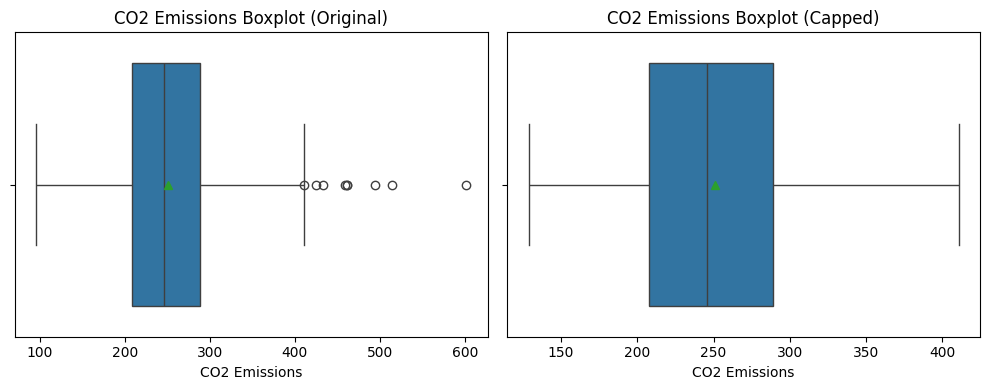

In [36]:
#Outlier detection for CO2 Emissions
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(x=df['CO2 Emissions'], showmeans=True)
plt.title('CO2 Emissions Boxplot (Original)')

# Cap extreme outliers at 99th percentile
q99 = df['CO2 Emissions'].quantile(0.99)
q1 = df['CO2 Emissions'].quantile(0.01)
df['CO2 Emissions'] = df['CO2 Emissions'].clip(lower=q1, upper=q99)

print("1st percentile (q1):", q1)
print("99th percentile (q99):", q99)

plt.subplot(1,2,2)
sns.boxplot(x=df['CO2 Emissions'], showmeans=True)
plt.title('CO2 Emissions Boxplot (Capped)')
plt.tight_layout()
plt.show()



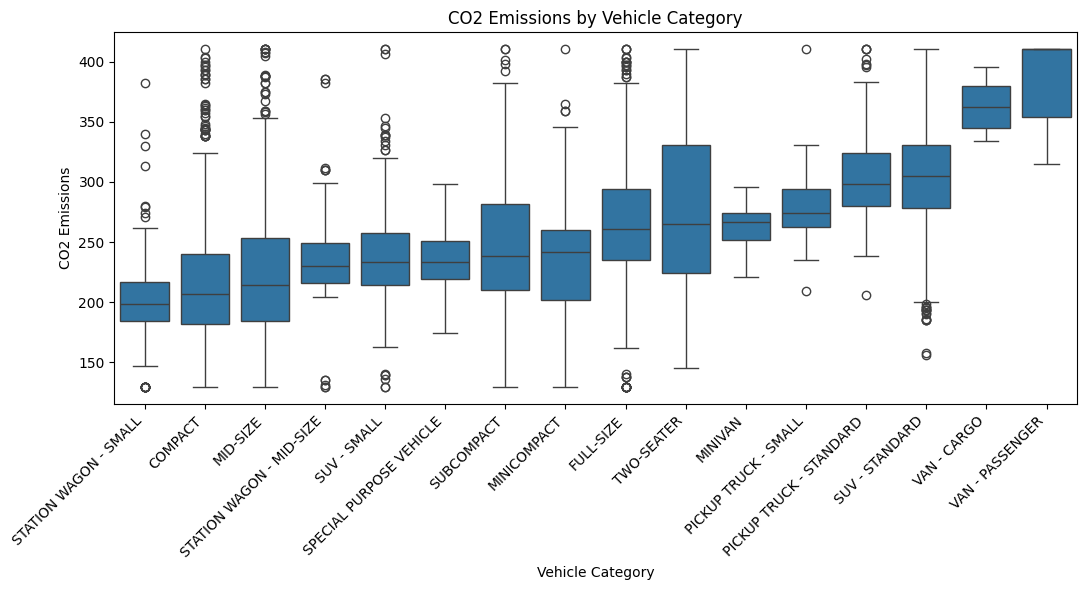

In [37]:
#CO2 Emissions by Vehicle Category
plt.figure(figsize=(11,6))
category_order = df.groupby('Vehicle Category')['CO2 Emissions'].median().sort_values().index
sns.boxplot(x='Vehicle Category', y='CO2 Emissions', data=df, order=category_order)
plt.xticks(rotation=45, ha='right')
plt.title('CO2 Emissions by Vehicle Category')
plt.tight_layout()
plt.show()

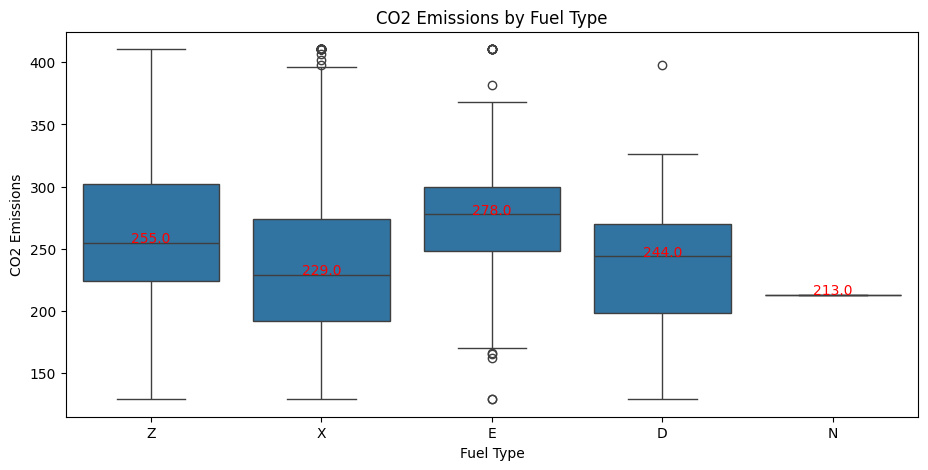

In [38]:
#CO2 Emissions by Fuel Type
plt.figure(figsize=(11,5))
ax = sns.boxplot(x='Fuel Type', y='CO2 Emissions', data=df)

# Add median labels
for i, category in enumerate(df['Fuel Type'].unique()):
    median = np.median(df[df['Fuel Type'] == category]['CO2 Emissions'])
    ax.text(i, median, f'{median:.1f}',
            horizontalalignment='center', color='red')

plt.title('CO2 Emissions by Fuel Type')
plt.show()

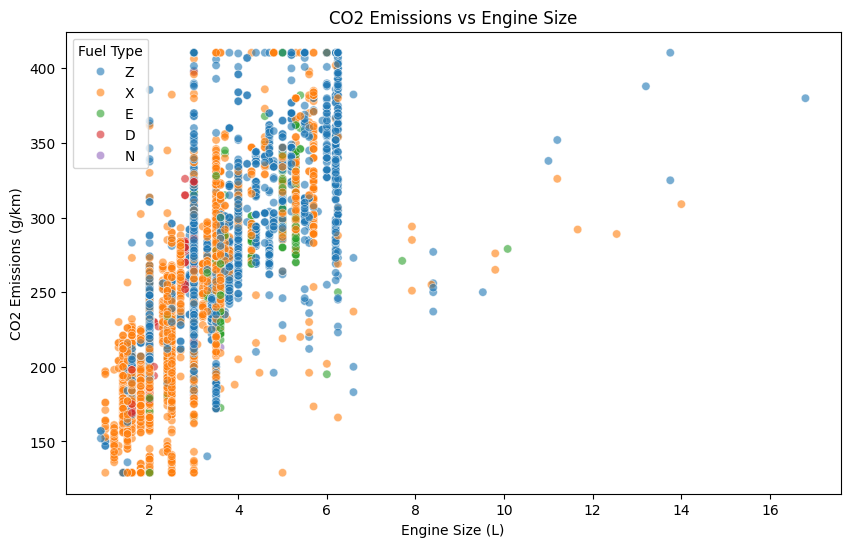

In [39]:
#CO2 Emissions vs Engine Size

plt.figure(figsize=(10,6))
sns.scatterplot(x='Engine Size', y='CO2 Emissions', hue='Fuel Type', data=df, alpha=0.6)
plt.title('CO2 Emissions vs Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

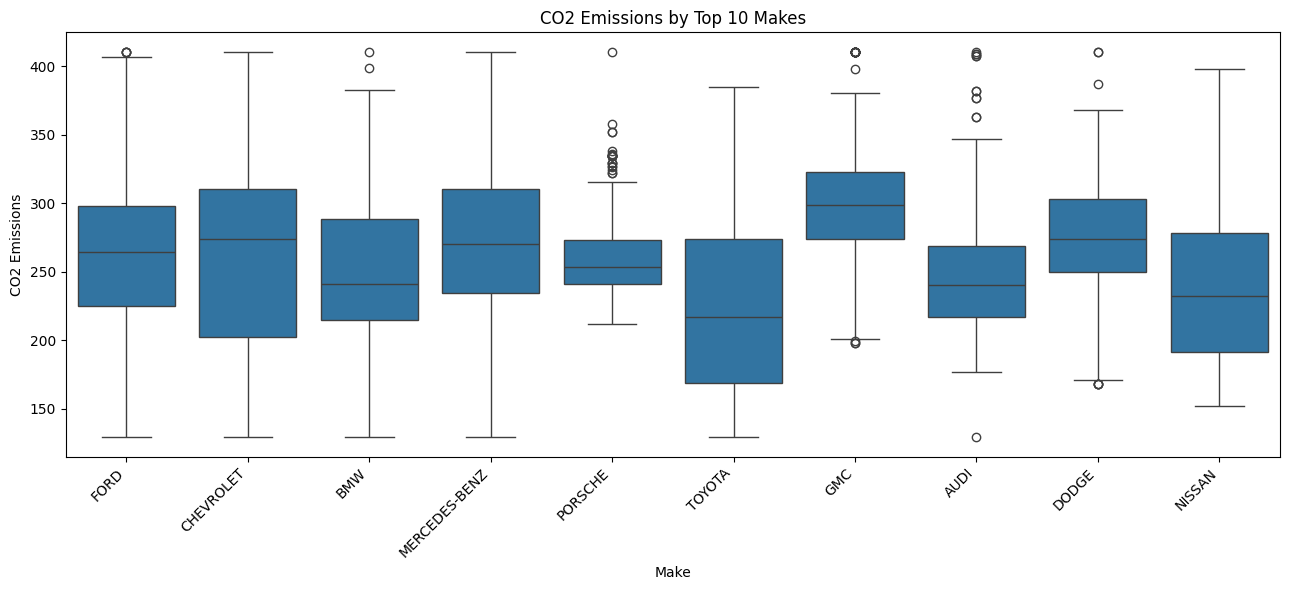

In [40]:
#CO2 Emissions by top 10 Make
top_makes = df['Make'].value_counts().nlargest(10).index
plt.figure(figsize=(13,6))
sns.boxplot(x='Make', y='CO2 Emissions', data=df[df['Make'].isin(top_makes)], order=top_makes)
plt.xticks(rotation=45, ha='right')
plt.title('CO2 Emissions by Top 10 Makes')
plt.tight_layout()
plt.show()

In [41]:
#Dealer comparison
dealer_emissions = df.groupby('Dealer_ID')['CO2 Emissions'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(dealer_emissions.head(10))

                 mean  count
Dealer_ID                   
D004       261.247414    116
D003       258.717391    115
D014       258.331579     95
D018       257.805344    131
D026       257.450495    101
D010       256.853906    128
D034       256.826957    115
D031       256.559211    114
D001       255.911818    110
D050       255.861702     94


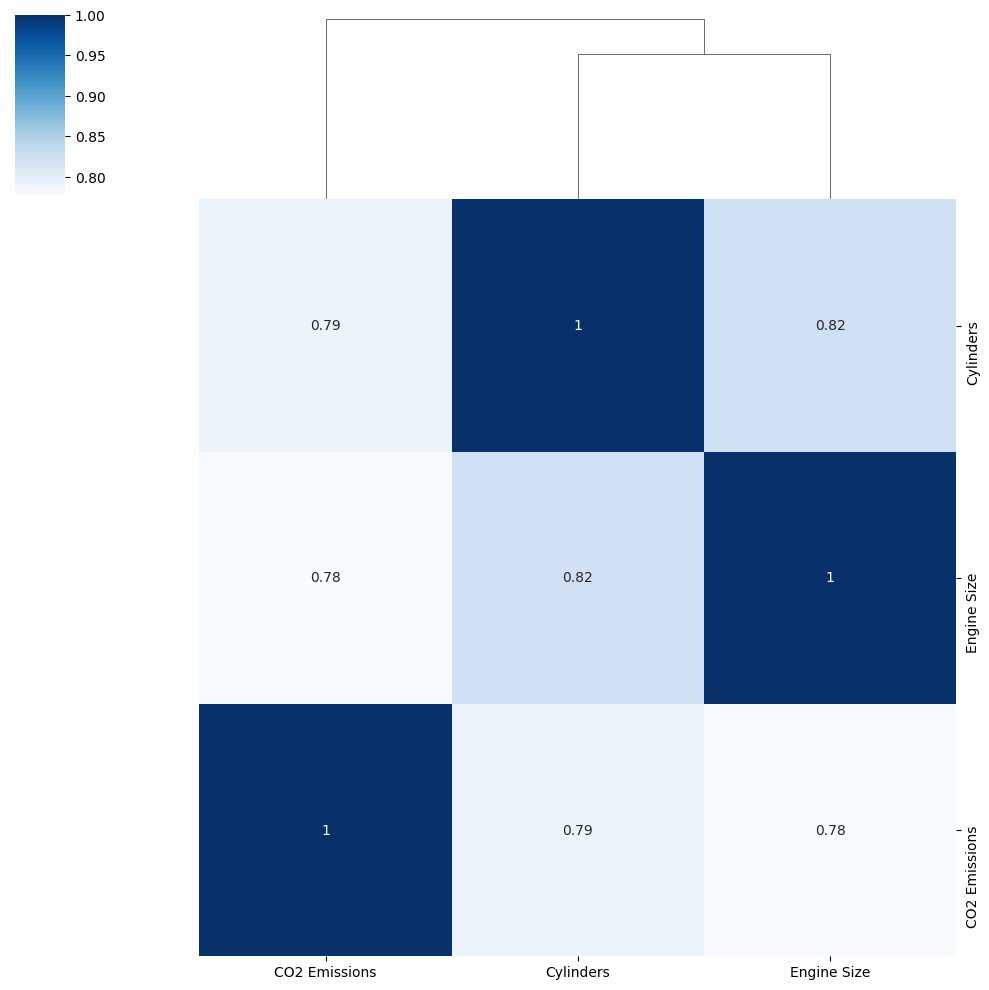

In [42]:
#Hierarchical clustering of feature correlations

sns.clustermap(df[numerical_variables].corr(),
               cmap='Blues', annot=True,
               row_cluster=False)
plt.show()

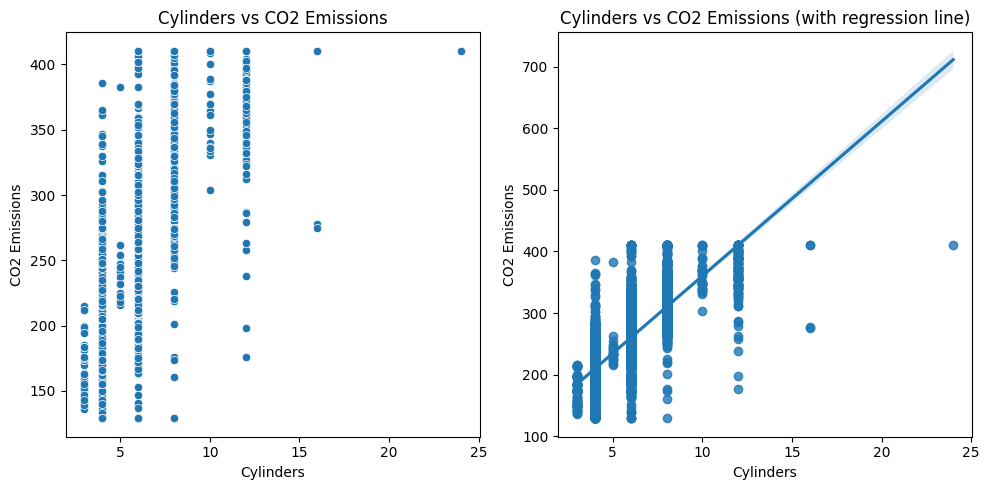

Correlation between Cylinders and CO2 Emissions: 0.79


In [43]:
#Cylinders vs CO2 Emissions Relationship

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Cylinders', y='CO2 Emissions')
plt.title('Cylinders vs CO2 Emissions')

plt.subplot(1, 2, 2)
sns.regplot(data=df, x='Cylinders', y='CO2 Emissions')
plt.title('Cylinders vs CO2 Emissions (with regression line)')

plt.tight_layout()
plt.show()

correlation = df['Cylinders'].corr(df['CO2 Emissions'])
print(f'Correlation between Cylinders and CO2 Emissions: {correlation:.2f}')

In [44]:
# Prepare modelling dataset — drop columns not used for prediction
df_ml = df.drop(columns=['Vehicle Colour', 'Listing Month', 'Dealer_ID'
                                                       ], errors='ignore')

print("Features for modelling:")
print([c for c in df_ml.columns if c != 'CO2 Emissions'])

# Encode categorical features using LabelEncoder
le_dict = {}
cat_features = ['Make', 'Vehicle Category', 'Fuel Type', 'Transmission Type', 'Dealer_State']
for col in cat_features:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le
    print(f"  {col}: {le.classes_[:5]}...")

# Define features (X) and target (y)
X = df_ml.drop('CO2 Emissions', axis=1)
y = df_ml['CO2 Emissions']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features for modelling:
['Dealer_State', 'Make', 'Vehicle Category', 'Transmission Type', 'Fuel Type', 'Cylinders', 'Engine Size']
  Make: ['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY']...
  Vehicle Category: ['COMPACT' 'FULL-SIZE' 'MID-SIZE' 'MINICOMPACT' 'MINIVAN']...
  Fuel Type: ['D' 'E' 'N' 'X' 'Z']...
  Transmission Type: ['A10' 'A4' 'A5' 'A6' 'A7']...
  Dealer_State: ['NSW' 'QLD' 'SA' 'TAS' 'VIC']...

X shape: (6685, 7)
y shape: (6685,)


In [45]:
#splitting Train-Test Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   {X_train.shape[0]} records ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} records ({X_test.shape[0]/len(X)*100:.1f}%)")


Training set:   5348 records (80.0%)
Test set:       1337 records (20.0%)


In [46]:
# Model 1: Linear Regression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred_lr = pipeline.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"  MAE:  {mae_lr:.2f} g/km")
print(f"  RMSE: {rmse_lr:.2f} g/km")
print(f"  R²:   {r2_lr:.4f}")

# Coefficients
lr = pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

print("\nCoefficients:")
print(coef_df.sort_values("Coefficient", ascending=False).to_string(index=False))

Linear Regression
  MAE:  23.39 g/km
  RMSE: 31.16 g/km
  R²:   0.7118

Coefficients:
          Feature  Coefficient
        Cylinders    26.471009
      Engine Size    20.339244
 Vehicle Category    10.330143
        Fuel Type     2.878909
     Dealer_State     0.229071
             Make    -0.448173
Transmission Type    -4.300608


In [47]:
# Model 2: Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(" Random Forest ")
print(f"  MAE:  {mae_rf:.2f} g/km")
print(f"  RMSE: {rmse_rf:.2f} g/km")
print(f"  R²:   {r2_rf:.4f}")

# Feature importances
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importances:")
print(feat_imp.to_string(index=False))

 Random Forest 
  MAE:  12.48 g/km
  RMSE: 19.38 g/km
  R²:   0.8885

Feature Importances:
          Feature  Importance
      Engine Size    0.527338
        Cylinders    0.254271
 Vehicle Category    0.079960
             Make    0.054665
Transmission Type    0.044531
        Fuel Type    0.023579
     Dealer_State    0.015656


In [48]:
# Model 3: Gradient Boosting

pipeline_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

pipeline_gb.fit(X_train, y_train)

y_pred_gb = pipeline_gb.predict(X_test)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print(" Gradient Boosting ")
print(f"  MAE:  {mae_gb:.2f} g/km")
print(f"  RMSE: {rmse_gb:.2f} g/km")
print(f"  R²:   {r2_gb:.4f}")

 Gradient Boosting 
  MAE:  15.19 g/km
  RMSE: 21.43 g/km
  R²:   0.8637


Model Performance Comparison
            Model     MAE    RMSE     R²
Linear Regression 23.3877 31.1613 0.7118
    Random Forest 12.4845 19.3823 0.8885
Gradient Boosting 15.1855 21.4317 0.8637

Test set CO2 mean: 250.51 g/km
Test set CO2 std:  58.07 g/km

Best model: Random Forest (R²=0.8885, RMSE=19.38 g/km)


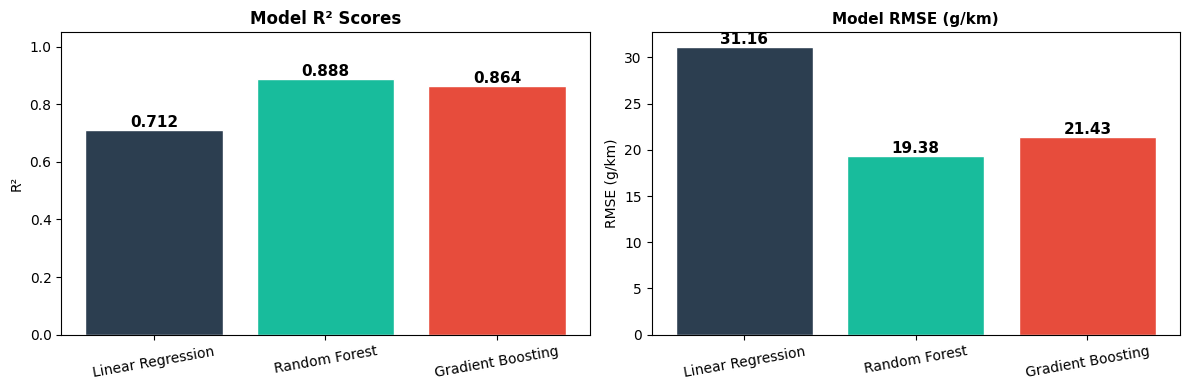

In [49]:
# Model Comparison Summary


results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R²': [r2_lr, r2_rf, r2_gb]
}).round(4)

print("Model Performance Comparison")
print(results.to_string(index=False))
print(f"\nTest set CO2 mean: {y_test.mean():.2f} g/km")
print(f"Test set CO2 std:  {y_test.std():.2f} g/km")
print(f"\nBest model: Random Forest (R²={r2_rf:.4f}, RMSE={rmse_rf:.2f} g/km)")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2C3E50', '#18BC9C', '#E74C3C']
models_list = results['Model'].tolist()

bars1 = axes[0].bar(models_list, results['R²'], color=colors, edgecolor='white')
axes[0].set_title('Model R² Scores', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars1, results['R²']):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                  ha='center', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

bars2 = axes[1].bar(models_list, results['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('Model RMSE (g/km)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('RMSE (g/km)')
for bar, val in zip(bars2, results['RMSE']):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.2f}',
                  ha='center', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

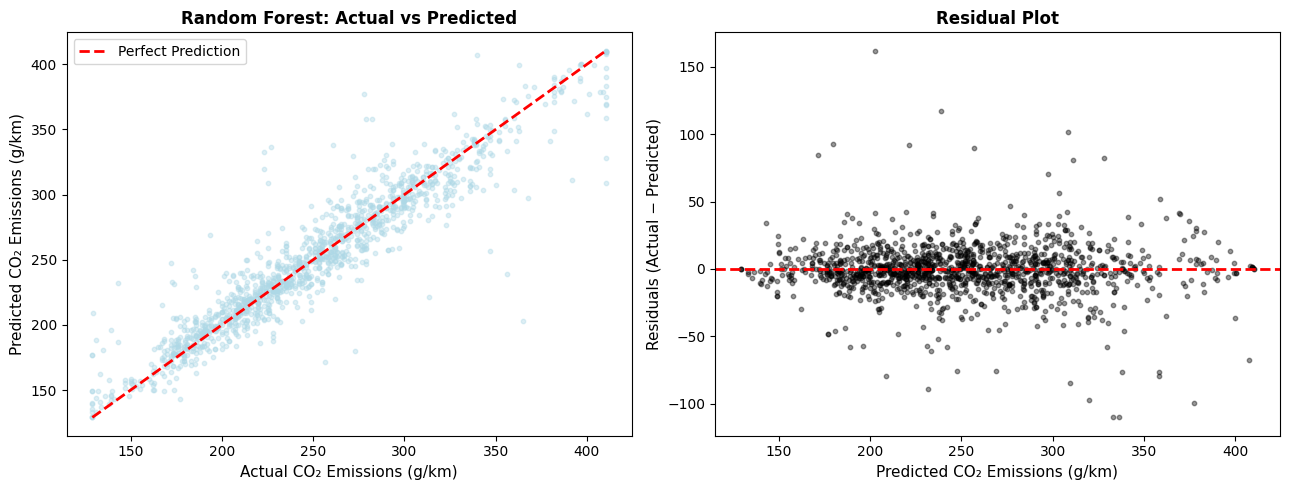

Residual mean: -0.7854 g/km
Residual std:  19.3736 g/km
Max over-prediction: -110.05 g/km
Max under-prediction: 161.89 g/km


In [50]:
#Random Forest Model: Actual vs Predicted & Residual Analysis


residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.4, s=10, color='lightblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual CO₂ Emissions (g/km)', fontsize=11)
axes[0].set_ylabel('Predicted CO₂ Emissions (g/km)', fontsize=11)
axes[0].set_title('Random Forest: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals vs Fitted
axes[1].scatter(y_pred_rf, residuals, alpha=0.4, s=10, color='black')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted CO₂ Emissions (g/km)', fontsize=11)
axes[1].set_ylabel('Residuals (Actual − Predicted)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f} g/km")
print(f"Residual std:  {residuals.std():.4f} g/km")
print(f"Max over-prediction: {residuals.min():.2f} g/km")
print(f"Max under-prediction: {residuals.max():.2f} g/km")

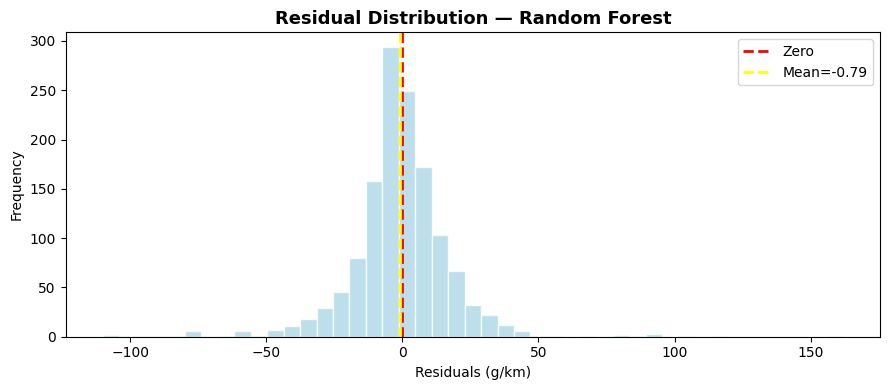

Skewness of residuals: 0.1994
Kurtosis of residuals: 10.3695


In [51]:
# Residual Distribution

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(residuals, bins=45, color='lightblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax.axvline(residuals.mean(), color='yellow', linestyle='--', linewidth=2,
            label=f'Mean={residuals.mean():.2f}')
ax.set_title('Residual Distribution — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Residuals (g/km)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness of residuals: {residuals.skew():.4f}")
print(f"Kurtosis of residuals: {residuals.kurt():.4f}")

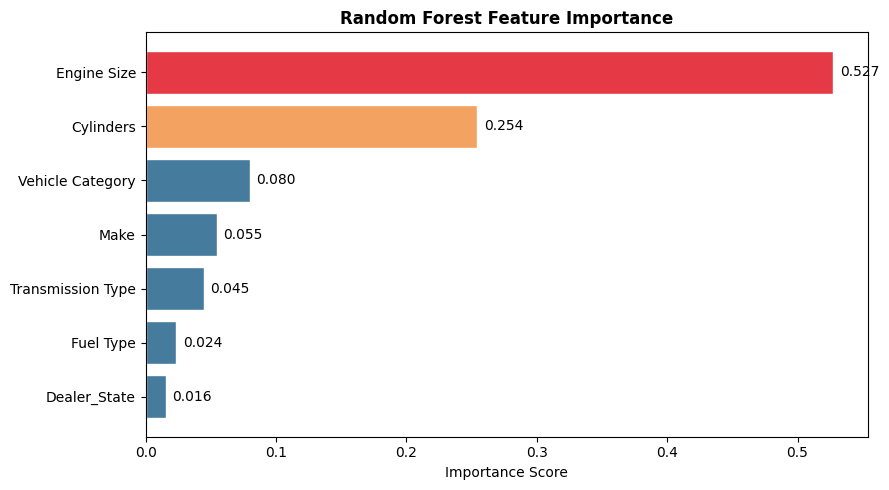

Feature Importance Summary:
          Feature  Importance
      Engine Size    0.527338
        Cylinders    0.254271
 Vehicle Category    0.079960
             Make    0.054665
Transmission Type    0.044531
        Fuel Type    0.023579
     Dealer_State    0.015656


In [52]:
# Random Forest - Feature Importance Plot

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp_sorted = feat_imp.sort_values('Importance')
colours = ['#E63946' if v > 0.3 else '#F4A261' if v > 0.1 else '#457B9D'
           for v in feat_imp_sorted['Importance']]
bars = ax.barh(feat_imp_sorted['Feature'], feat_imp_sorted['Importance'],
                color=colours, edgecolor='white')
for bar, val in zip(bars, feat_imp_sorted['Importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
ax.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importance Summary:")
print(feat_imp.to_string(index=False))

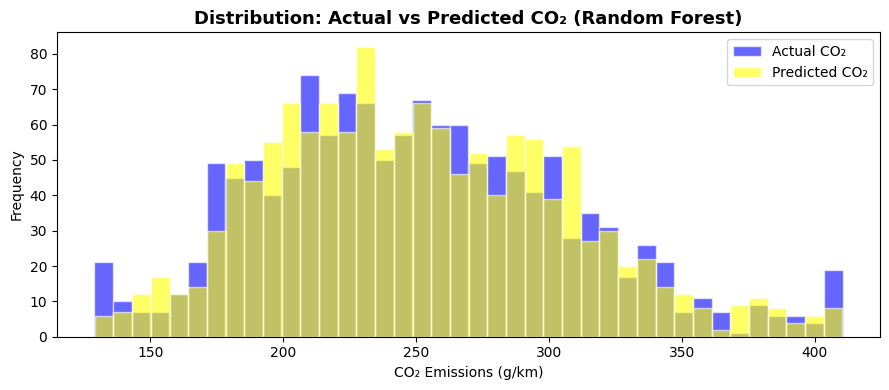

Actual  — mean: 250.51, std: 58.07, min: 129.0, max: 410.5
Predicted—mean: 251.30, std: 55.37, min: 129.2, max: 410.4


In [53]:
# Compare Predicted vs Actual Distributions

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_test, bins=40, alpha=0.6, color='blue', label='Actual CO₂', edgecolor='white')
ax.hist(y_pred_rf, bins=40, alpha=0.6, color='yellow', label='Predicted CO₂', edgecolor='white')
ax.set_title('Distribution: Actual vs Predicted CO₂ (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('CO₂ Emissions (g/km)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Actual  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}, min: {y_test.min():.1f}, max: {y_test.max():.1f}")
print(f"Predicted—mean: {y_pred_rf.mean():.2f}, std: {y_pred_rf.std():.2f}, min: {y_pred_rf.min():.1f}, max: {y_pred_rf.max():.1f}")